In [74]:
#Import necesary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [75]:
#Load the dataset
df_insurance = pd.read_csv(r"C:\Users\Admin\Desktop\EJ's Own Things (Do not touch)\Machine Learning\Python Code\Linear Regression\Health Insurance Linear Regression\insurance.csv")

In [76]:
#Check the first few rows of the dataset
df_insurance.head()


,age,sex,bmi,children,smoker,region,charges in thousand dollars
0,19,female,27.900,0,yes,southwest,16.88
1,18,male,33.770,1,no,southeast,1.73
2,28,male,33.000,3,no,southeast,4.45
3,33,male,22.705,0,no,northwest,21.98
4,32,male,28.880,0,no,northwest,3.87


In [24]:
#Dataset Exploration
print("Number of rows and columns:", df_insurance.shape)

Number of rows and columns: (1338, 7)


In [77]:
#Ensure that the values in sex and smoker columns are consistent (e.g., no leading/trailing spaces, consistent case)
df_insurance['sex'] = df_insurance['sex'].str.strip().str.lower()
df_insurance['smoker'] = df_insurance['smoker'].str.strip().str.lower()


In [78]:
#Check the first few rows of the dataset again to confirm changes
print(df_insurance.head())

   age     sex     bmi  children smoker     region  \
0   19  female  27.900         0    yes  southwest   
1   18    male  33.770         1     no  southeast   
2   28    male  33.000         3     no  southeast   
3   33    male  22.705         0     no  northwest   
4   32    male  28.880         0     no  northwest   

   charges in thousand dollars  
0                        16.88  
1                         1.73  
2                         4.45  
3                        21.98  
4                         3.87  


In [79]:
#Encode binary categorical variables
df_insurance['sex'] = df_insurance['sex'].map({'male': 1, 'female': 0}) 
df_insurance['smoker'] = df_insurance['smoker'].map({'yes': 1, 'no': 0})

#One-hot encode region
df_insurance = pd.get_dummies(df_insurance , columns=['region'], drop_first=True)
print("Unique values in 'sex':", df_insurance['sex'].unique()) 
print("Unique values in 'smoker':", df_insurance['smoker'].unique())

print(df_insurance.head())

Unique values in 'sex': [0 1]
Unique values in 'smoker': [1 0]
   age  sex     bmi  children  smoker  charges in thousand dollars  \
0   19    0  27.900         0       1                        16.88   
1   18    1  33.770         1       0                         1.73   
2   28    1  33.000         3       0                         4.45   
3   33    1  22.705         0       0                        21.98   
4   32    1  28.880         0       0                         3.87   

   region_northwest  region_southeast  region_southwest  
0             False             False              True  
1             False              True             False  
2             False              True             False  
3              True             False             False  
4              True             False             False  


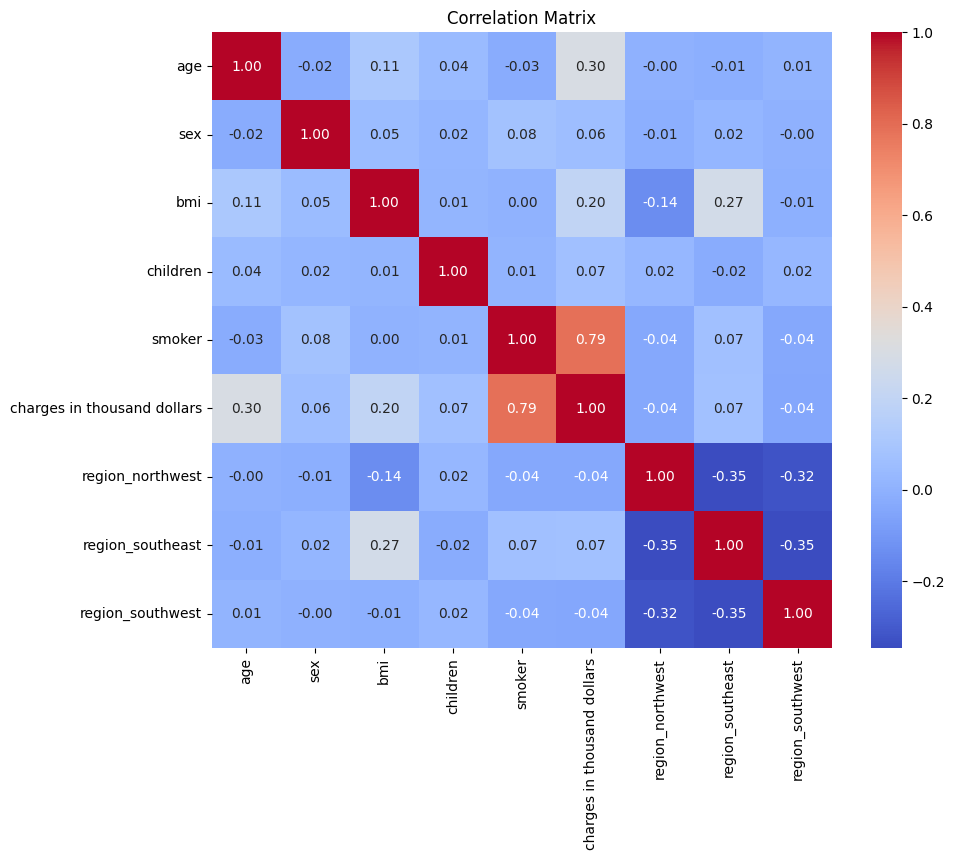

In [80]:
# Generate correlation matrix
corr_matrix = df_insurance.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Upon checking at the correlation matrix, we can temporarily drop the columns containing regions, the children they have, and the patient's sex. Adjust this if needed.

In [36]:
''' #Drop the columns with low correlation with the target variable
df_insurance = df_insurance.drop(columns=['sex', 'children', 'region_northwest', 'region_southeast', 'region_southwest'])
print(df_insurance.head()) '''

   age     bmi  smoker  charges in thousand dollars
0   19  27.900       1                        16.88
1   18  33.770       0                         1.73
2   28  33.000       0                         4.45
3   33  22.705       0                        21.98
4   32  28.880       0                         3.87


In [81]:
# Separate features and target
X = df_insurance.drop(columns=['charges in thousand dollars'])
y = df_insurance['charges in thousand dollars']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [83]:
#Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

Mean Absolute Error (MAE): 4.180968536333474
Mean Squared Error (MSE): 33.594210985956366
Root Mean Squared Error (RMSE): 5.796051327063656
R-squared (R²): 0.7836064161035307


In [84]:
#Use L1 Regression (Lasso)
from sklearn.linear_model import Lasso

# Create and fit the Lasso regression model (using default alpha=1.0, can tune later if needed)
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

# Predict on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Calculate metrics for Lasso
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = mse_lasso ** 0.5
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression Metrics:")
print(f"Mean Absolute Error (MAE): {mae_lasso}")
print(f"Mean Squared Error (MSE): {mse_lasso}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso}")
print(f"R-squared (R²): {r2_lasso}")

Lasso Regression Metrics:
Mean Absolute Error (MAE): 4.268350351165571
Mean Squared Error (MSE): 34.24296322795161
Root Mean Squared Error (RMSE): 5.85174873246892
R-squared (R²): 0.7794275466320939


In [85]:
#Use L2 Regression (Ridge)
from sklearn.linear_model import Ridge

# Create and fit the Ridge regression model (using default alpha=1.0, can tune later if needed)
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

# Predict on the test set
y_pred_ridge = ridge_model.predict(X_test)

# Calculate metrics for Ridge
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = mse_ridge ** 0.5
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression Metrics:")
print(f"Mean Absolute Error (MAE): {mae_ridge}")
print(f"Mean Squared Error (MSE): {mse_ridge}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge}")
print(f"R-squared (R²): {r2_ridge}")

Ridge Regression Metrics:
Mean Absolute Error (MAE): 4.182202193281246
Mean Squared Error (MSE): 33.59878607144271
Root Mean Squared Error (RMSE): 5.7964459862438735
R-squared (R²): 0.7835769461705879


In [86]:
#Use Elastic Net Regression (Combination of L1 and L2)
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create and fit the Elastic Net regression model (using default alpha=1.0 and l1_ratio=0.5, can tune later if needed)
elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.9)
elastic_net_model.fit(X_train, y_train)

# Predict on the test set
y_pred_elastic = elastic_net_model.predict(X_test)

# Calculate metrics for Elastic Net
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
rmse_elastic = mse_elastic ** 0.5
r2_elastic = r2_score(y_test, y_pred_elastic)

print(f"Elastic Net Regression Metrics:")
print(f"Mean Absolute Error (MAE): {mae_elastic}")
print(f"Mean Squared Error (MSE): {mse_elastic}")
print(f"Root Mean Squared Error (RMSE): {rmse_elastic}")
print(f"R-squared (R²): {r2_elastic}")

Elastic Net Regression Metrics:
Mean Absolute Error (MAE): 4.387705399880383
Mean Squared Error (MSE): 35.0771735509833
Root Mean Squared Error (RMSE): 5.922598547173639
R-squared (R²): 0.7740540683980099


In [99]:
#Use Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create polynomial features (degree 2, as it performed best)
poly = PolynomialFeatures(degree=2)

# Transform the training and test sets
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and fit the polynomial regression model
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

# Predict on the test set
y_pred_poly = model_poly.predict(X_test_poly)

# Calculate metrics
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = mse_poly ** 0.5
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression (Degree 2) Metrics:")
print(f"Mean Absolute Error (MAE): {mae_poly}")
print(f"Mean Squared Error (MSE): {mse_poly}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly}")
print(f"R-squared (R²): {r2_poly}")

Polynomial Regression (Degree 2) Metrics:
Mean Absolute Error (MAE): 2.7296655857540904
Mean Squared Error (MSE): 20.71215925485182
Root Mean Squared Error (RMSE): 4.551061332793903
R-squared (R²): 0.8665848001828218


In [104]:


# Create a DataFrame with actual values, predictions, and errors for each model
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Linear_Pred': y_pred,
    'Ridge_Pred': y_pred_ridge,
    'Lasso_Pred': y_pred_lasso,
    'Poly_Pred': y_pred_poly,
    'Linear_Error': y_test - y_pred,
    'Ridge_Error': y_test - y_pred_ridge,
    'Lasso_Error': y_test - y_pred_lasso,
    'Poly_Error': y_test - y_pred_poly
})

#Export the errors DataFrame to a CSV file
errors_df.to_csv(r"C:\Users\Admin\Desktop\EJ's Own Things (Do not touch)\Machine Learning\Python Code\Linear Regression\Health Insurance Linear Regression\model_errors.csv", index=False)


print(errors_df)

      Actual  Linear_Pred  Ridge_Pred  Lasso_Pred  Poly_Pred  Linear_Error  \
764     9.10     8.969790    8.971620    8.628627  11.216353      0.130210   
887     5.27     7.069079    7.071308    7.171215   6.055392     -1.799079   
890    29.33    36.858582   36.846659   36.366050  33.306092     -7.528582   
1293    9.30     9.455077    9.458161    9.432914  10.834946     -0.155077   
259    33.75    26.973256   26.962898   26.475965  29.082559      6.776744   
...      ...          ...         ...         ...        ...           ...   
109    47.06    39.061091   39.050763   38.775042  46.683122      7.998909   
575    12.22    11.761798   11.763661   11.880195  12.569819      0.458202   
535     6.07     7.687543    7.690194    7.398472   7.463138     -1.617543   
543    63.77    40.919870   40.908651   40.471668  57.475924     22.850130   
846     9.87    12.318482   12.320577   12.733809  11.213301     -2.448482   

      Ridge_Error  Lasso_Error  Poly_Error  
764      0.128380 

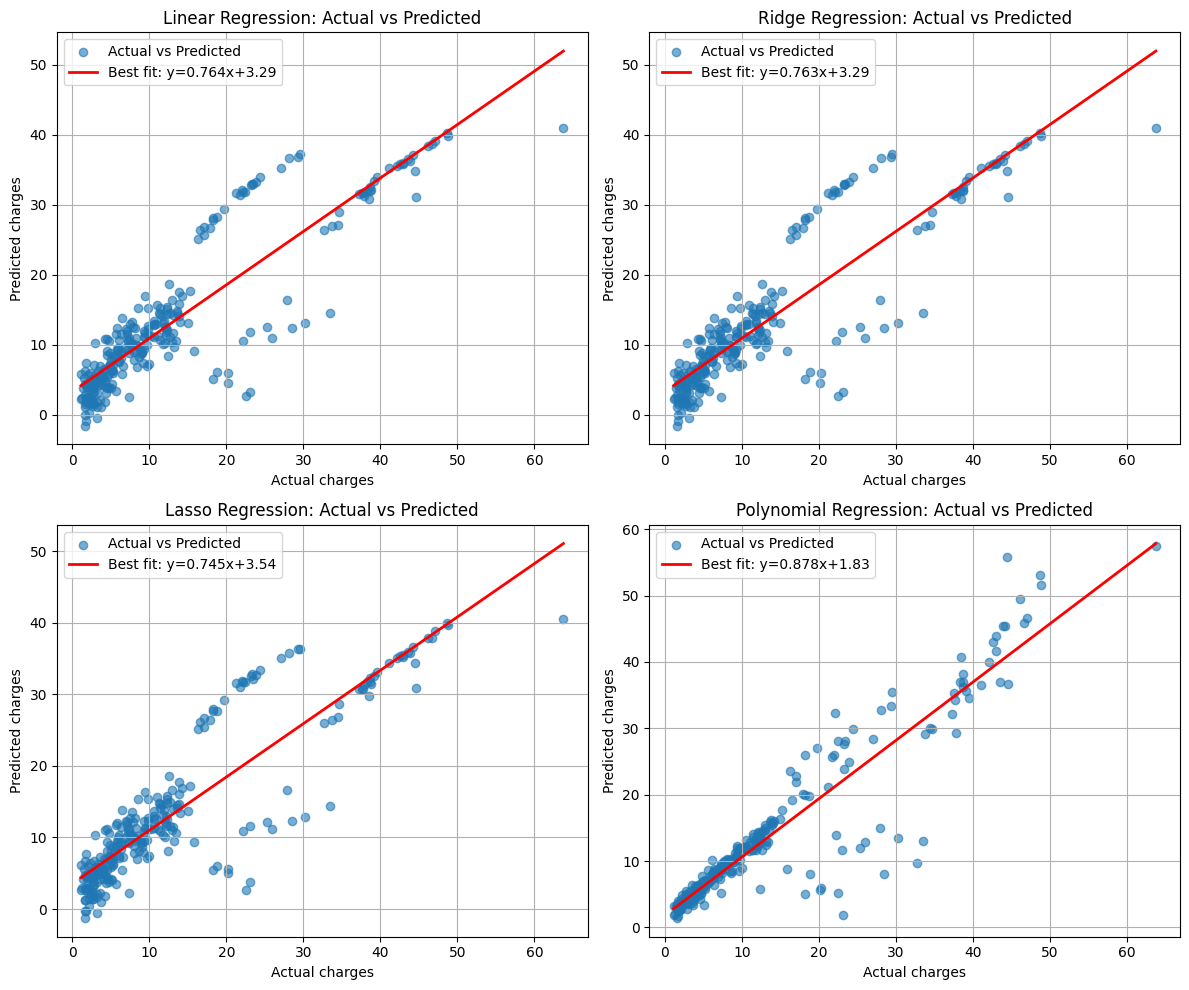

In [105]:
import numpy as np

import matplotlib.pyplot as plt

# Define the models and their predictions
models = ['Linear', 'Ridge', 'Lasso', 'Polynomial']
predictions = [y_pred, y_pred_ridge, y_pred_lasso, y_pred_poly]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (model, pred) in enumerate(zip(models, predictions)):
	ax = axes[i]
	ax.scatter(y_test, pred, alpha=0.6, label='Actual vs Predicted')
	m, b = np.polyfit(y_test, pred, 1)
	x_line = np.linspace(y_test.min(), y_test.max(), 100)
	ax.plot(x_line, m * x_line + b, color='red', lw=2, label=f'Best fit: y={m:.3f}x+{b:.2f}')
	#ax.plot(x_line, x_line, color='green', lw=1, ls='--', label='Ideal y=x')
	ax.set_xlabel('Actual charges')
	ax.set_ylabel('Predicted charges')
	ax.set_title(f'{model} Regression: Actual vs Predicted')
	ax.legend()
	ax.grid(True)

plt.tight_layout()
plt.show()